In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
url = "https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv"
local_file = Path("car_fuel_efficiency_2026.csv")
df = pd.read_csv(local_file if local_file.exists() else url)
features = ["engine_displacement", "horsepower", "vehicle_weight", "model_year"]
target = "fuel_efficiency_mpg"
df = df[features + [target]].copy()
print("Shape:", df.shape)
df.head()

Shape: (10000, 5)


,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,2180,243.0,3870,2006,31.9
1,2390,272.0,4210,2008,31.3
2,2320,267.0,4240,1996,27.5
3,2130,258.0,4490,1989,28.5
4,2580,304.0,4510,1994,31.0


## EDA, Q1 and Q2
Check the target distribution, missing values and horsepower median.

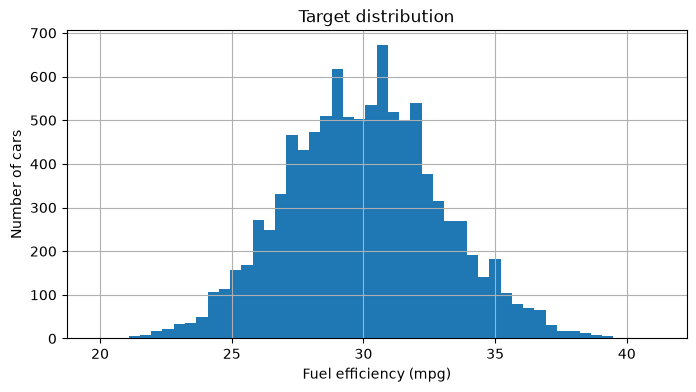

count    10000.000000
mean        29.997700
std          2.930245
min         19.800000
25%         28.000000
50%         30.000000
75%         31.900000
max         41.200000
Name: fuel_efficiency_mpg, dtype: float64
Skewness: 0.08080419601878173
Missing values:
engine_displacement      0
horsepower             877
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64
Q2 median: 254.0


In [2]:
df[target].hist(bins=50, figsize=(8, 4))
plt.xlabel("Fuel efficiency (mpg)")
plt.ylabel("Number of cars")
plt.title("Target distribution")
plt.show()
print(df[target].describe())
print("Skewness:", df[target].skew())
print("Missing values:")
print(df.isna().sum())
print("Q2 median:", df.horsepower.median())

In [3]:
def split_data(df, seed):
    n = len(df)
    n_val = int(n * 0.2)
    n_test = int(n * 0.2)
    n_train = n - n_val - n_test
    np.random.seed(seed)
    idx = np.arange(n)
    np.random.shuffle(idx)
    df_train = df.iloc[idx[:n_train]].copy()
    df_val = df.iloc[idx[n_train:n_train + n_val]].copy()
    df_test = df.iloc[idx[n_train + n_val:]].copy()
    return df_train, df_val, df_test

def prepare_X(frame, fill_value=0):
    return frame[features].fillna(fill_value).values

def train_linear_regression(X, y, r=0):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])
    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])
    w = np.linalg.inv(XTX).dot(X.T).dot(y)
    return w[0], w[1:]

def predict(X, w0, w):
    return w0 + X.dot(w)

def rmse(y, y_pred):
    return np.sqrt(((y - y_pred) ** 2).mean())

df_train, df_val, df_test = split_data(df, 42)
y_train = df_train[target].values
y_val = df_val[target].values
print("Train / validation / test:", len(df_train), len(df_val), len(df_test))

Train / validation / test: 6000 2000 2000


## Q3 — Zero vs training mean imputation

In [4]:
missing_column = df[features].isna().sum().idxmax()
train_mean = df_train[missing_column].mean()
q3_rows = []
for name, fill in [("With 0", 0), ("With mean", train_mean)]:
    w0, w = train_linear_regression(prepare_X(df_train, fill), y_train)
    score = rmse(y_val, predict(prepare_X(df_val, fill), w0, w))
    q3_rows.append({"Option": name, "RMSE": score, "Rounded RMSE": round(score, 3)})
q3 = pd.DataFrame(q3_rows)
print("Training mean:", train_mean)
print(q3.to_string(index=False))
q3_answer = "Both are equally good" if q3["Rounded RMSE"].nunique() == 1 else q3.loc[q3["Rounded RMSE"].idxmin(), "Option"]
print("Q3 answer:", q3_answer)

Training mean: 254.46338337605272
   Option     RMSE  Rounded RMSE
   With 0 2.205293         2.205
With mean 2.201817         2.202
Q3 answer: With mean


## Q4 — Regularization
Select the smallest r among tied rounded scores.

In [5]:
q4_rows = []
for r in [0, 0.01, 0.1, 1, 5, 10, 100]:
    w0, w = train_linear_regression(prepare_X(df_train), y_train, r)
    score = rmse(y_val, predict(prepare_X(df_val), w0, w))
    q4_rows.append({"r": r, "RMSE": score, "Rounded RMSE": round(score, 4)})
q4 = pd.DataFrame(q4_rows)
print(q4.to_string(index=False))
q4_answer = q4.sort_values(["Rounded RMSE", "r"]).iloc[0]["r"]
print("Q4 answer:", q4_answer)

     r     RMSE  Rounded RMSE
  0.00 2.205293        2.2053
  0.01 2.205828        2.2058
  0.10 2.224143        2.2241
  1.00 2.349229        2.3492
  5.00 2.409380        2.4094
 10.00 2.419470        2.4195
100.00 2.429202        2.4292
Q4 answer: 0.0


## Q5 — Split stability
Calculate np.std on unrounded RMSE values, then round the standard deviation.

In [6]:
q5_rows = []
for seed in range(10):
    train, val, test = split_data(df, seed)
    w0, w = train_linear_regression(prepare_X(train), train[target].values)
    score = rmse(val[target].values, predict(prepare_X(val), w0, w))
    q5_rows.append({"Seed": seed, "Validation RMSE": score})
q5 = pd.DataFrame(q5_rows)
q5_std = np.std(q5["Validation RMSE"].values)
print(q5.to_string(index=False))
print("Standard deviation:", q5_std)
print("Q5 answer:", round(q5_std, 3))

 Seed  Validation RMSE
    0         2.239204
    1         2.202113
    2         2.163420
    3         2.204359
    4         2.201880
    5         2.245785
    6         2.269721
    7         2.190795
    8         2.216611
    9         2.207037
Standard deviation: 0.028781274078191175
Q5 answer: 0.029


## Q6 — Final test evaluation
Seed 9, train + validation combined, zero imputation and r=0.001. Test data is excluded from fitting.

In [7]:
train, val, test = split_data(df, 9)
full_train = pd.concat([train, val], ignore_index=True)
w0, w = train_linear_regression(prepare_X(full_train), full_train[target].values, r=0.001)
q6_score = rmse(test[target].values, predict(prepare_X(test), w0, w))
print("Test RMSE:", q6_score)
print("Rounded to 3 decimals:", round(q6_score, 3))

Test RMSE: 2.235827747191731
Rounded to 3 decimals: 2.236


In [8]:
answers = pd.DataFrame({"Question": ["Q1", "Q2", "Q3", "Q4", "Q5", "Q6"],
                        "Answer": [missing_column, df.horsepower.median(), q3_answer, q4_answer, round(q5_std, 3), q6_score]})
print(answers.to_string(index=False))

Question     Answer
      Q1 horsepower
      Q2      254.0
      Q3  With mean
      Q4        0.0
      Q5      0.029
      Q6   2.235828
